# 01 — Exploratory Data Analysis

**Prediction unit:** one client. **Target:** whether that client is associated with electricity/gas consumption fraud.

This notebook establishes data quality, class balance, table relationships, observation windows, and the first client-level behavioral features. The invoice table is processed in chunks so the full 4.5M-row training file does not need to live in memory.

**How to use it:** run the notebook top to bottom once, then discuss the findings marked in the final section before moving to the baseline model. The raw source is read from Parquet for efficient, repeatable local execution; the optional output remains a small CSV with one row per client.

## Stakeholder question and success criteria

Assumption: a utility investigation team has limited capacity and wants a ranked list of clients for inspection. The model should surface fraud while avoiding too many unproductive inspections.

- Primary development metric: **average precision (PR-AUC)**.
- Operational metrics: **precision@k** and **recall@k**, where `k` is inspection capacity.
- Secondary diagnostics: ROC-AUC, confusion matrix, and segment-level performance.

Before final modeling, confirm the cost of an inspection, the cost of missed fraud, inspection capacity, and whether labels refer to a fixed point in time. Those answers determine `k` and the threshold; a probability of 0.5 is not automatically a sensible operational cutoff.

For this first pass, use the charts to form hypotheses—not to declare causes. A difference between fraud and non-fraud clients can come from genuine behavior, data collection, or a longer observation period.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pyarrow.parquet as pq
from IPython.display import display
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PARQUET_DIR = DATA_DIR / "parquet"
CHUNK_SIZE = 250_000
SAVE_FEATURES = False
AS_OF_DATE = None  # Example: "2018-12-31"; required for a real deployment backtest.
FINAL_HOLDOUT_SIZE = 0.20
RANDOM_STATE = 42

required_files = [PARQUET_DIR / "client_train.parquet", PARQUET_DIR / "invoice_train.parquet"]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required files: {missing_files}. See README.md for data setup.")

print(f"Using Parquet data from: {PARQUET_DIR.resolve()}")

Using Parquet data from: /Users/skress/Documents/spiced/ml_project/ds-fraud-in-electricity-and-gas/data/parquet


## 1. Understand the two-table data model

`client_train.parquet` has one row per client and contains the target. `invoice_train.parquet` has many dated invoices per client. The safe modeling table therefore has one row per client after invoice aggregation. Splitting invoice rows would put the same client into both train and validation and produce leakage.

The relationship is **one client to many invoices**. Client fields describe who the customer is; invoice fields describe a sequence of readings and consumption events. In this notebook we turn that sequence into summary features such as history length, mean consumption, zero-consumption rate, activity span, and electricity/gas mix. Later iterations can add trends and recent-versus-historical changes.

In [2]:
client = pd.read_parquet(PARQUET_DIR / "client_train.parquet")
client["client_id"] = client["client_id"].astype("string")
client["creation_date"] = pd.to_datetime(client["creation_date"], dayfirst=True, errors="raise")
client["target"] = client["target"].astype("int8")

client_overview = pd.DataFrame({
    "rows": [len(client)],
    "unique_clients": [client["client_id"].nunique()],
    "duplicate_rows": [client.duplicated().sum()],
    "missing_cells": [int(client.isna().sum().sum())],
    "fraud_rate": [client["target"].mean()],
})
display(client_overview)
display(client.head())
display(client.dtypes.rename("dtype").to_frame())

assert client["client_id"].is_unique, "Expected one row per client."
assert set(client["target"].unique()) <= {0, 1}, "Target must be binary."

development_ids, final_holdout_ids = train_test_split(
    client["client_id"],
    test_size=FINAL_HOLDOUT_SIZE,
    stratify=client["target"],
    random_state=RANDOM_STATE,
)
final_holdout_ids = set(final_holdout_ids)
client["split"] = np.where(client["client_id"].isin(final_holdout_ids), "final_holdout", "development")
display(pd.crosstab(client["split"], client["target"], margins=True))

,rows,unique_clients,duplicate_rows,missing_cells,fraud_rate
0,135493,135493,0,0,0.055841


,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0
1,69,train_Client_1,11,107,2002-05-29,0
2,62,train_Client_10,11,301,1986-03-13,0
3,69,train_Client_100,11,105,1996-07-11,0
4,62,train_Client_1000,11,303,2014-10-14,0


,dtype
disrict,int16
client_id,string
client_catg,int16
region,int16
creation_date,datetime64[us]
target,int8


target,0,1,All
split,,,
development,102341,6053,108394
final_holdout,25586,1513,27099
All,127927,7566,135493


,clients,share
target,,
0,102341,0.944157
1,6053,0.055843


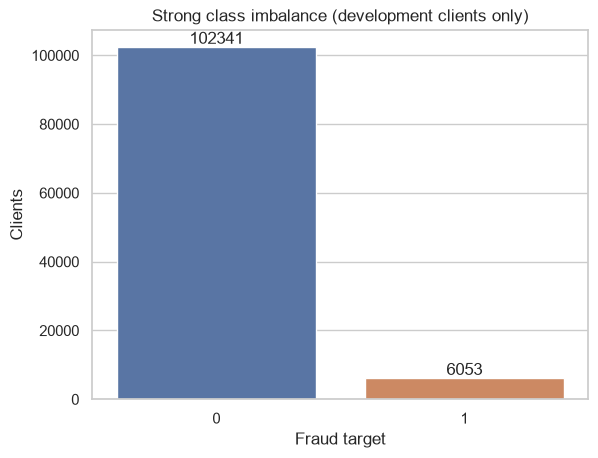

In [3]:
eda_client = client.query("split == 'development'").copy()
target_summary = (
    eda_client["target"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .to_frame("clients")
)
target_summary["share"] = target_summary["clients"] / len(eda_client)
display(target_summary)

ax = sns.countplot(data=eda_client, x="target", hue="target", legend=False)
ax.set(title="Strong class imbalance (development clients only)", xlabel="Fraud target", ylabel="Clients")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()

## 2. Audit and aggregate invoice history

The source column names `disrict` and `counter_statue` are misspelled; they are preserved to match the supplied schema. The cell below computes exact additive/min/max client aggregates in chunks and records missing values and unexpected index direction without retaining all invoice rows.

Parquet is used here because it has a fixed column schema and can be read in record batches. That avoids the mixed-type CSV issue in `counter_statue` and keeps the browser kernel from attempting to hold the full invoice table at once.

In [4]:
invoice_parquet = pq.ParquetFile(PARQUET_DIR / "invoice_train.parquet")
invoice_sample = invoice_parquet.read_row_group(0).to_pandas().head(5_000)
invoice_sample["invoice_date"] = pd.to_datetime(invoice_sample["invoice_date"], errors="raise")
display(invoice_sample.head())
display(invoice_sample.dtypes.rename("inferred_dtype").to_frame())
print(f"Sample shape: {invoice_sample.shape}")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


,inferred_dtype
client_id,str
invoice_date,datetime64[us]
tarif_type,int16
counter_number,int64
counter_statue,str
counter_code,int16
reading_remarque,int16
counter_coefficient,int16
consommation_level_1,int64
consommation_level_2,int64


Sample shape: (5000, 16)


In [5]:
CONSUMPTION_COLUMNS = [f"consommation_level_{level}" for level in range(1, 5)]

def aggregate_invoices(path, chunk_size=250_000, as_of_date=None):
    partials = []
    row_hashes = []
    missing_counts = None
    status_counts = pd.Series(dtype="int64")
    tariff_counts = pd.Series(dtype="int64")
    source_rows = 0
    total_rows = 0
    excluded_after_cutoff = 0
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None
    started = time.perf_counter()

    parquet_file = pq.ParquetFile(path)
    reader = parquet_file.iter_batches(batch_size=chunk_size)

    for chunk_number, batch in enumerate(reader, start=1):
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        source_rows += len(chunk)
        if cutoff is not None:
            after_cutoff = chunk["invoice_date"].gt(cutoff)
            excluded_after_cutoff += int(after_cutoff.sum())
            chunk = chunk.loc[~after_cutoff].copy()
        total_rows += len(chunk)
        row_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())
        chunk_missing = chunk.isna().sum()
        missing_counts = chunk_missing if missing_counts is None else missing_counts.add(chunk_missing, fill_value=0)
        status_counts = status_counts.add(chunk["counter_statue"].value_counts(), fill_value=0)
        tariff_counts = tariff_counts.add(chunk["tarif_type"].value_counts(), fill_value=0)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["zero_consumption"] = chunk["total_consumption"].eq(0).astype("int8")
        chunk["is_elec"] = chunk["counter_type"].eq("ELEC").astype("int8")
        chunk["is_gaz"] = chunk["counter_type"].eq("GAZ").astype("int8")
        chunk["index_went_backwards"] = chunk["index_delta"].lt(0).astype("int8")

        grouped = chunk.groupby("client_id", observed=True).agg(
            invoice_count=("client_id", "size"),
            first_invoice=("invoice_date", "min"),
            last_invoice=("invoice_date", "max"),
            total_consumption_sum=("total_consumption", "sum"),
            total_consumption_max=("total_consumption", "max"),
            index_delta_sum=("index_delta", "sum"),
            index_delta_min=("index_delta", "min"),
            index_delta_max=("index_delta", "max"),
            months_sum=("months_number", "sum"),
            zero_consumption_count=("zero_consumption", "sum"),
            elec_invoice_count=("is_elec", "sum"),
            gaz_invoice_count=("is_gaz", "sum"),
            backwards_index_count=("index_went_backwards", "sum"),
        )
        partials.append(grouped.reset_index())
        if chunk_number % 5 == 0:
            print(f"Processed {total_rows:,} invoice rows...")

    partial = pd.concat(partials, ignore_index=True)
    client_agg = partial.groupby("client_id", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        first_invoice=("first_invoice", "min"),
        last_invoice=("last_invoice", "max"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        total_consumption_max=("total_consumption_max", "max"),
        index_delta_sum=("index_delta_sum", "sum"),
        index_delta_min=("index_delta_min", "min"),
        index_delta_max=("index_delta_max", "max"),
        months_sum=("months_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
        elec_invoice_count=("elec_invoice_count", "sum"),
        gaz_invoice_count=("gaz_invoice_count", "sum"),
        backwards_index_count=("backwards_index_count", "sum"),
    )

    client_agg["mean_consumption"] = client_agg["total_consumption_sum"] / client_agg["invoice_count"]
    client_agg["mean_index_delta"] = client_agg["index_delta_sum"] / client_agg["invoice_count"]
    client_agg["mean_months"] = client_agg["months_sum"] / client_agg["invoice_count"]
    client_agg["zero_consumption_rate"] = client_agg["zero_consumption_count"] / client_agg["invoice_count"]
    client_agg["elec_share"] = client_agg["elec_invoice_count"] / client_agg["invoice_count"]
    client_agg["active_days"] = (client_agg["last_invoice"] - client_agg["first_invoice"]).dt.days

    invoice_hashes = pd.Series(np.concatenate(row_hashes), copy=False)
    audit = {
        "source_invoice_rows": source_rows,
        "invoice_rows": total_rows,
        "excluded_after_cutoff": excluded_after_cutoff,
        "duplicate_row_hash_matches": int(invoice_hashes.duplicated().sum()),
        "invoice_clients": client_agg["client_id"].nunique(),
        "missing_by_column": missing_counts.sort_values(ascending=False),
        "counter_status_counts": status_counts.sort_index().astype("int64"),
        "tariff_counts": tariff_counts.sort_index().astype("int64"),
        "elapsed_seconds": time.perf_counter() - started,
    }
    return client_agg, audit

In [6]:
invoice_features, invoice_audit = aggregate_invoices(
    PARQUET_DIR / "invoice_train.parquet",
    chunk_size=CHUNK_SIZE,
    as_of_date=AS_OF_DATE,
)

print(f"Processed {invoice_audit['invoice_rows']:,} rows in {invoice_audit['elapsed_seconds']:.1f}s")
display(invoice_features.head())
display(invoice_audit["missing_by_column"].rename("missing_values").to_frame())
display(invoice_audit["counter_status_counts"].rename("invoice_rows").to_frame())
display(invoice_audit["tariff_counts"].rename("invoice_rows").to_frame())

Processed 1,250,000 invoice rows...


Processed 2,500,000 invoice rows...


Processed 3,750,000 invoice rows...


Processed 4,476,749 rows in 1.4s


,client_id,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days
0,train_Client_0,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,362.971429,362.971429,4.628571,0.0,1.0,4901
1,train_Client_1,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,557.540541,557.540541,4.324324,0.0,1.0,4913
2,train_Client_10,18,2005-11-10,2019-05-02,15057,3082,15057,188,3082,116,0,18,0,0,836.5,836.5,6.444444,0.0,1.0,4921
3,train_Client_100,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,1.2,1.2,4.2,0.8,1.0,2664
4,train_Client_1000,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,922.642857,922.642857,3.714286,0.0,1.0,1585


,missing_values
client_id,0
invoice_date,0
tarif_type,0
counter_number,0
counter_statue,0
counter_code,0
reading_remarque,0
counter_coefficient,0
consommation_level_1,0
consommation_level_2,0


,invoice_rows
counter_statue,
0,4379008
1,74036
2,32
269375,1
3,258
4,2729
420,1
46,14
5,20639


,invoice_rows
tarif_type,
8,43
9,6039
10,276210
11,2679872
12,11345
13,11656
14,11611
15,72422
18,4


In [7]:
unknown_invoice_clients = set(invoice_features["client_id"]) - set(client["client_id"])
clients_without_invoices = set(client["client_id"]) - set(invoice_features["client_id"])
print(f"Invoice clients absent from client table: {len(unknown_invoice_clients):,}")
print(f"Clients without invoices: {len(clients_without_invoices):,}")

analysis = client.merge(
    invoice_features,
    on="client_id",
    how="left",
    validate="one_to_one",
)
analysis["customer_tenure_days_at_last_invoice"] = (
    analysis["last_invoice"] - analysis["creation_date"]
).dt.days

assert len(analysis) == len(client)
assert not unknown_invoice_clients
display(analysis.head())

eda_analysis = analysis.query("split == 'development'").copy()
print(f"EDA uses {len(eda_analysis):,} development clients; {analysis['split'].eq('final_holdout').sum():,} final-holdout clients remain excluded from target comparisons.")

Invoice clients absent from client table: 0
Clients without invoices: 0


,disrict,client_id,client_catg,region,creation_date,target,split,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days,customer_tenure_days_at_last_invoice
0,60,train_Client_0,11,101,1994-12-31,0,development,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,362.971429,362.971429,4.628571,0.0,1.0,4901,8844
1,69,train_Client_1,11,107,2002-05-29,0,development,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,557.540541,557.540541,4.324324,0.0,1.0,4913,6152
2,62,train_Client_10,11,301,1986-03-13,0,final_holdout,18,2005-11-10,2019-05-02,15057,3082,15057,188,3082,116,0,18,0,0,836.5,836.5,6.444444,0.0,1.0,4921,12103
3,69,train_Client_100,11,105,1996-07-11,0,development,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,1.2,1.2,4.2,0.8,1.0,2664,5920
4,62,train_Client_1000,11,303,2014-10-14,0,development,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,922.642857,922.642857,3.714286,0.0,1.0,1585,1707


EDA uses 108,394 development clients; 27,099 final-holdout clients remain excluded from target comparisons.


## 3. Compare client history and behavior by target

These are associations, not causal explanations. Large differences may indicate signal, label-collection bias, or different observation windows. Review both medians and distributions because consumption variables are heavy-tailed.

The plots use `log1p` for count and consumption features so a handful of very large customers do not hide the overall pattern. Boxplots suppress extreme points visually, but the numeric summary still includes every development client. If a feature differs by target, ask whether it is available at the time an inspection decision would be made.

target                                                 0            1
invoice_count                        median         29.0         41.0
                                     mean      32.339092    46.472989
active_days                          median       3286.0       4739.0
                                     mean    2973.785795  3997.584008
mean_consumption                     median   393.257143        469.0
                                     mean     640.279714   771.546954
total_consumption_max                median       1284.0       2010.0
                                     mean    2235.049794  3543.457459
zero_consumption_rate                median     0.017544     0.037975
                                     mean       0.127785     0.106461
mean_index_delta                     median    386.16129   451.583333
                                     mean     615.667517   738.684787
mean_months                          median          4.2     4.210526
                                     mean      31.728445    52.300647
elec_share                           median          1.0     0.641791
                                     mean       0.789927     0.735988
customer_tenure_days_at_last_invoice median       4036.0       6303.0
                                     mean     5155.24991  6878.158103

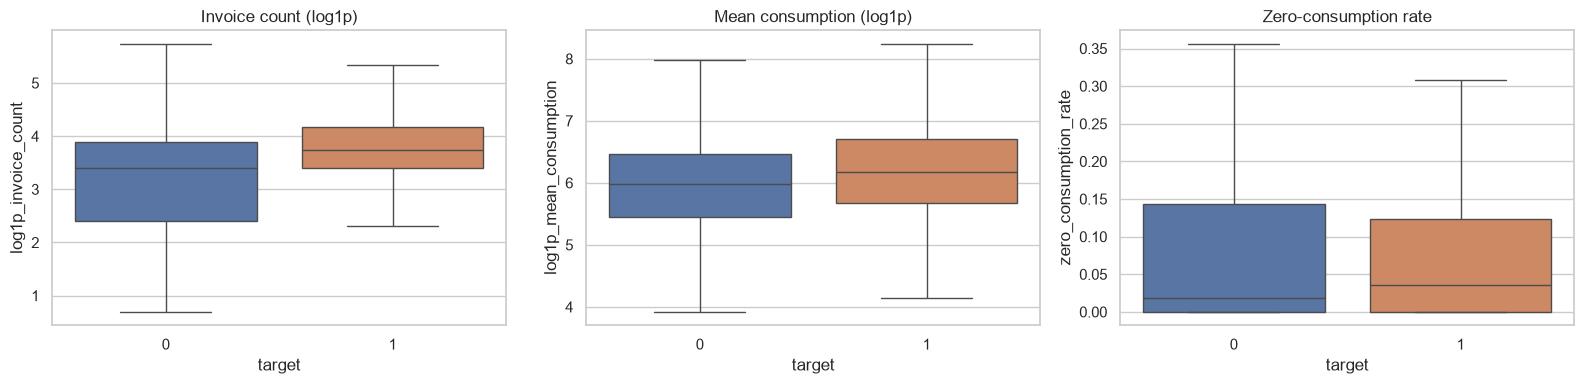

In [8]:
eda_features = [
    "invoice_count",
    "active_days",
    "mean_consumption",
    "total_consumption_max",
    "zero_consumption_rate",
    "mean_index_delta",
    "mean_months",
    "elec_share",
    "customer_tenure_days_at_last_invoice",
]

summary_by_target = eda_analysis.groupby("target")[eda_features].agg(["median", "mean"])
display(summary_by_target.T)

plot_sample = eda_analysis.sample(n=min(40_000, len(eda_analysis)), random_state=RANDOM_STATE).copy()
plot_sample["log1p_invoice_count"] = np.log1p(plot_sample["invoice_count"])
plot_sample["log1p_mean_consumption"] = np.log1p(plot_sample["mean_consumption"].clip(lower=0))
plot_sample["log1p_max_consumption"] = np.log1p(plot_sample["total_consumption_max"].clip(lower=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column, title in zip(
    axes,
    ["log1p_invoice_count", "log1p_mean_consumption", "zero_consumption_rate"],
    ["Invoice count (log1p)", "Mean consumption (log1p)", "Zero-consumption rate"],
):
    sns.boxplot(data=plot_sample, x="target", y=column, hue="target", legend=False, showfliers=False, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Full distributional view.** Boxplots above are compact but hide shape — multimodality, spikes
at zero, how heavy the tail really is. The grid below shows all nine `eda_features` as histograms,
normalized to density (`common_norm=False`) so the small fraud group's shape is directly
comparable to the much larger non-fraud group despite the class-size difference.

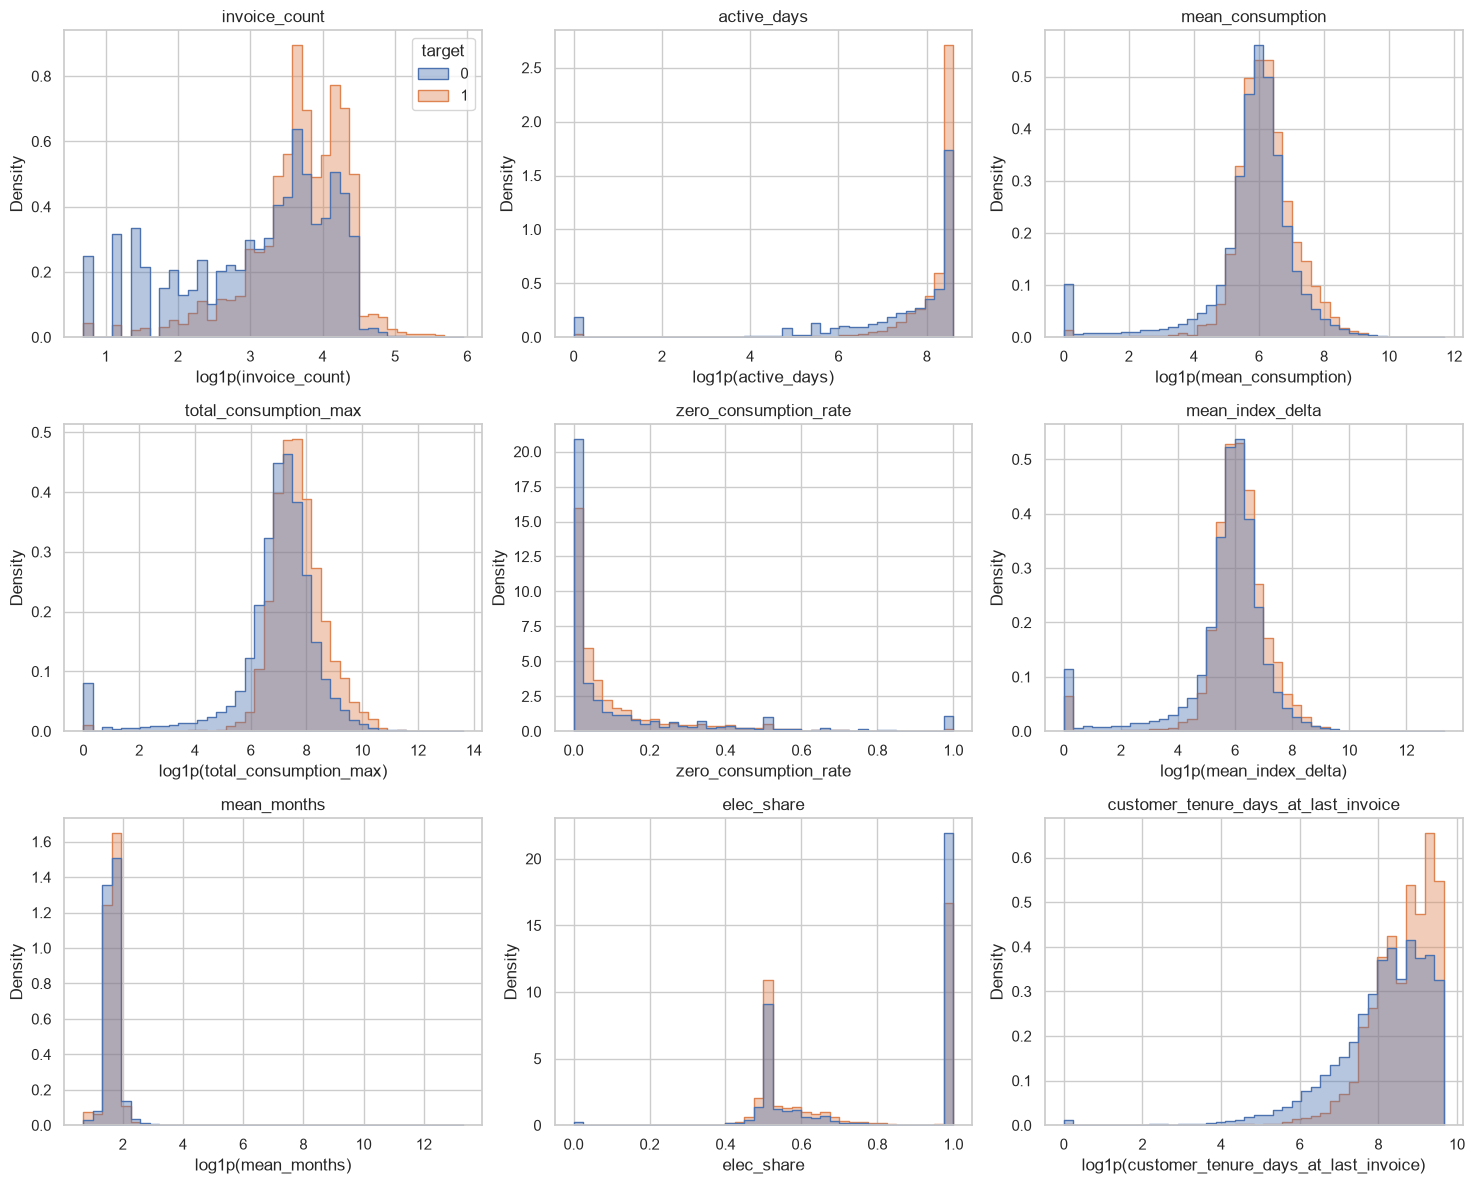

In [9]:
log_features = {
    "invoice_count", "active_days", "mean_consumption", "total_consumption_max",
    "customer_tenure_days_at_last_invoice", "mean_months", "mean_index_delta",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, (ax, feature) in enumerate(zip(axes.flat, eda_features)):
    plot_frame = eda_analysis[["target"]].copy()
    if feature in log_features:
        plot_frame["value"] = np.log1p(eda_analysis[feature].clip(lower=0))
        xlabel = f"log1p({feature})"
    else:
        plot_frame["value"] = eda_analysis[feature]
        xlabel = feature
    sns.histplot(
        data=plot_frame, x="value", hue="target", stat="density", common_norm=False,
        bins=40, element="step", alpha=0.4, ax=ax, legend=(i == 0),
    )
    ax.set_title(feature)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

,clients,fraud_rate
client_catg,,
51,1299,0.169361
11,105216,0.054726
12,1879,0.039915


,clients,fraud_rate
region,,
103,7144,0.102744
372,510,0.096078
311,9966,0.080273
106,578,0.079585
371,1639,0.076266
313,1658,0.075995
304,3056,0.070353
379,467,0.068522
107,7990,0.065582


,clients,fraud_rate
history_length_bin,,
"(57.0, 380.0]",21448,0.090125
"(36.0, 57.0]",21879,0.076420
"(22.0, 36.0]",21053,0.067259
"(7.0, 22.0]",22301,0.037128
"(0.999, 7.0]",21713,0.009395


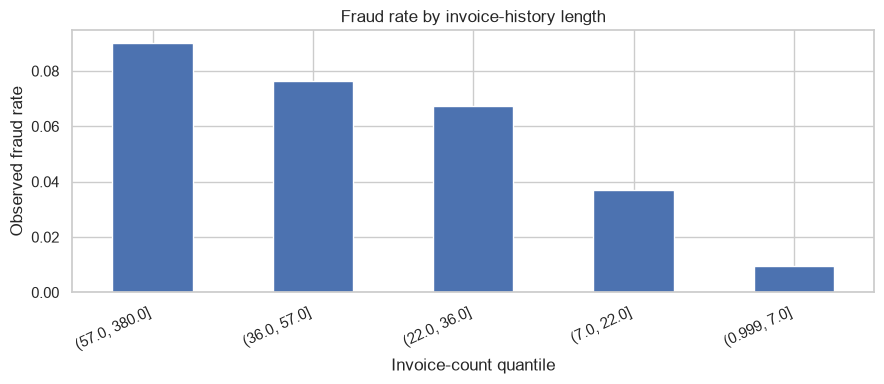

In [10]:
def fraud_rate_by_group(frame, column, minimum_clients=50):
    result = frame.groupby(column, dropna=False)["target"].agg(clients="size", fraud_rate="mean")
    return result.query("clients >= @minimum_clients").sort_values("fraud_rate", ascending=False)

display(fraud_rate_by_group(eda_analysis, "client_catg"))
display(fraud_rate_by_group(eda_analysis, "region").head(20))

eda_analysis["history_length_bin"] = pd.qcut(
    eda_analysis["invoice_count"],
    q=5,
    duplicates="drop",
)
history_bias = fraud_rate_by_group(eda_analysis, "history_length_bin", minimum_clients=1)
display(history_bias)

ax = history_bias["fraud_rate"].plot(kind="bar", figsize=(9, 4), title="Fraud rate by invoice-history length")
ax.set(xlabel="Invoice-count quantile", ylabel="Observed fraud rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [11]:
display(fraud_rate_by_group(eda_analysis, "disrict"))

bias_ratio = history_bias["fraud_rate"].iloc[0] / history_bias["fraud_rate"].iloc[-1]
print(
    f"Observation-window check: fraud rate is {bias_ratio:.1f}x higher in the longest-history "
    f"quintile ({history_bias['fraud_rate'].iloc[0]:.1%}) than the shortest-history quintile "
    f"({history_bias['fraud_rate'].iloc[-1]:.1%}). This is a strong signal that history length "
    "itself is confounded with the label and needs explicit handling before modeling."
)

,clients,fraud_rate
disrict,,
69,27391,0.070936
63,23207,0.064894
62,32336,0.052016
60,25460,0.036214


Observation-window check: fraud rate is 9.6x higher in the longest-history quintile (9.0%) than the shortest-history quintile (0.9%). This is a strong signal that history length itself is confounded with the label and needs explicit handling before modeling.


**What these checks say together:**

- `client_catg == 51` stands out clearly — a real, large-enough-to-trust segment (not noise) with
  a fraud rate roughly 3× the overall base rate.
- `region`/`disrict` fraud rates vary by roughly 2–3× across categories — worth encoding as
  categorical features, and worth checking model performance per-region later rather than trusting
  one global score.
- **The invoice-count/history-length quintile chart above is the most important one on this page.**
  Fraud rate rises sharply and close to monotonically with how many invoices a client has on file
  (printed above). That is exactly the observation-window bias flagged in `00_project_plan.md`
  §2.3: a model trained naively on this may partly learn "has been a customer a long time" rather
  than "is committing fraud," which would not generalize to newer clients. This needs to be
  addressed explicitly before or during modeling — e.g. compare performance within tenure bands,
  or treat history length as a feature whose effect we understand rather than an accidental proxy.

In [12]:
quality_checks = pd.Series({
    "duplicate_client_rows": int(client.duplicated().sum()),
    "duplicate_client_ids": int(client["client_id"].duplicated().sum()),
    "missing_client_cells": int(client.isna().sum().sum()),
    "missing_invoice_cells": int(invoice_audit["missing_by_column"].sum()),
    "duplicate_invoice_row_hash_matches": invoice_audit["duplicate_row_hash_matches"],
    "clients_without_invoices": len(clients_without_invoices),
    "invoice_clients_without_client_row": len(unknown_invoice_clients),
    "clients_with_backwards_index": int(analysis["backwards_index_count"].gt(0).sum()),
    "creation_after_first_invoice": int(analysis["creation_date"].gt(analysis["first_invoice"]).sum()),
    "negative_customer_tenure": int(analysis["customer_tenure_days_at_last_invoice"].lt(0).sum()),
}, name="count")
display(quality_checks.to_frame())

display(analysis[["creation_date", "first_invoice", "last_invoice"]].agg(["min", "max"]))

,count
duplicate_client_rows,0
duplicate_client_ids,0
missing_client_cells,0
missing_invoice_cells,0
duplicate_invoice_row_hash_matches,11
clients_without_invoices,0
invoice_clients_without_client_row,0
clients_with_backwards_index,1816
creation_after_first_invoice,8748
negative_customer_tenure,397


,creation_date,first_invoice,last_invoice
min,1977-02-05,1977-06-09,1977-06-16
max,2019-09-10,2019-12-07,2019-12-07


## 4. Meter-reading integrity: does the index reconcile with reported consumption?

Two checks the public kernels researched for `00_project_plan.md` (§4) didn't do (see plan §2.5):

1. **Index reconciliation.** `new_index − old_index` should roughly match the sum of
   `consommation_level_1..4` for the same invoice. Large, systematic mismatches are a
   physically-motivated fraud/tampering signal — arguably more meaningful than any status code,
   since it's checking whether the meter's own counter agrees with what was billed.
2. **`months_number` outliers.** A handful of invoices report an implausible billing period (tens
   of thousands of "months"). Left unchecked, a single such row would badly distort any `mean`/`sum`
   aggregate built on it — including `mean_months` in the client table above. This check quantifies
   how big a problem that actually is before we decide whether to cap, clip, or drop those rows.

Both checks stream the invoice file in the same chunked pattern as the aggregation above, so the
full file still never needs to sit in memory at once.

In [13]:
def audit_meter_reconciliation(path, chunk_size=250_000, months_number_max_plausible=36, large_mismatch_threshold=10):
    """Check whether new_index - old_index reconciles with reported consumption
    (consommation_level_1..4), and flag months_number values beyond any plausible
    billing period. Note: a first attempt at this used a fixed "valid" set of
    {1, 2, 3, 4, 6, 12}, which flagged 7% of rows as outliers -- but the real
    full-file distribution shows 8, 16, 10, 20, 14, 24, and 18 are also common,
    legitimate multi-period bills. A threshold of 36 months (3 years) is a more
    defensible "physically implausible" cutoff, and only flags ~0.04% of rows.
    Also tracks invoice volume/consumption by calendar year to check for cohort
    or recording-practice effects."""
    client_partials = []
    year_partials = []
    months_outlier_rows = 0
    months_max_seen = 0
    total_rows = 0

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "old_index", "new_index", "months_number", *CONSUMPTION_COLUMNS]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        total_rows += len(chunk)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["reconciliation_gap_abs"] = (chunk["index_delta"] - chunk["total_consumption"]).abs()
        chunk["invoice_year"] = chunk["invoice_date"].dt.year
        chunk["is_months_outlier"] = chunk["months_number"] > months_number_max_plausible

        months_outlier_rows += int(chunk["is_months_outlier"].sum())
        months_max_seen = max(months_max_seen, int(chunk["months_number"].max()))

        client_grouped = chunk.groupby("client_id", observed=True).agg(
            reconciliation_gap_abs_sum=("reconciliation_gap_abs", "sum"),
            reconciliation_gap_abs_max=("reconciliation_gap_abs", "max"),
            row_count=("reconciliation_gap_abs", "size"),
            large_mismatch_count=("reconciliation_gap_abs", lambda s: int((s > large_mismatch_threshold).sum())),
            months_outlier_count=("is_months_outlier", "sum"),
        )
        client_partials.append(client_grouped.reset_index())

        year_grouped = chunk.groupby("invoice_year", observed=True).agg(
            invoice_count=("total_consumption", "size"),
            total_consumption_sum=("total_consumption", "sum"),
            zero_consumption_count=("total_consumption", lambda s: int((s == 0).sum())),
        )
        year_partials.append(year_grouped.reset_index())

    client_partial = pd.concat(client_partials, ignore_index=True)
    client_recon = client_partial.groupby("client_id", as_index=False).agg(
        reconciliation_gap_abs_sum=("reconciliation_gap_abs_sum", "sum"),
        reconciliation_gap_abs_max=("reconciliation_gap_abs_max", "max"),
        row_count=("row_count", "sum"),
        large_mismatch_count=("large_mismatch_count", "sum"),
        months_outlier_count=("months_outlier_count", "sum"),
    )
    client_recon["reconciliation_gap_abs_mean"] = client_recon["reconciliation_gap_abs_sum"] / client_recon["row_count"]

    year_partial = pd.concat(year_partials, ignore_index=True)
    year_trend = year_partial.groupby("invoice_year", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
    )
    year_trend["mean_consumption_per_invoice"] = year_trend["total_consumption_sum"] / year_trend["invoice_count"]
    year_trend["zero_consumption_rate"] = year_trend["zero_consumption_count"] / year_trend["invoice_count"]

    audit = {
        "total_rows": total_rows,
        "months_outlier_rows": months_outlier_rows,
        "months_outlier_share": months_outlier_rows / total_rows,
        "months_max_seen": months_max_seen,
    }
    return client_recon, year_trend, audit

months_number outliers: 1,859 of 4,476,749 rows (0.0415%); largest value seen: 636,624
Clients with at least one large index/consumption mismatch (>10 units): 7,728 of 135,493


,clients,reconciliation_gap_abs_mean,reconciliation_gap_abs_median,share_with_large_mismatch,share_with_months_outlier
target,,,,,
0,102341,76.459175,0.0,0.055638,0.003303
1,6053,126.225897,0.0,0.087064,0.002643


,invoice_year,invoice_count,total_consumption_sum,zero_consumption_count,mean_consumption_per_invoice,zero_consumption_rate
0,1977,10,1062,2,106.200000,0.200000
1,1978,56,4672,14,83.428571,0.250000
2,1979,129,80429,22,623.480620,0.170543
3,1980,158,34486,17,218.265823,0.107595
4,1981,205,50552,34,246.595122,0.165854
5,1982,197,55210,38,280.253807,0.192893
6,1983,157,37217,29,237.050955,0.184713
7,1984,812,128188,83,157.866995,0.102217
8,1985,471,100604,59,213.596603,0.125265
9,1986,422,88652,83,210.075829,0.196682


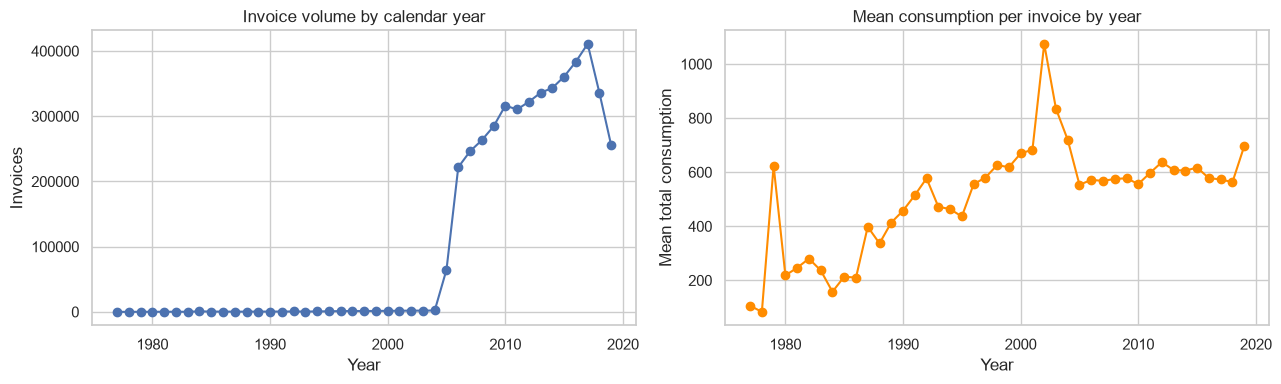

In [14]:
meter_recon, year_trend, meter_audit = audit_meter_reconciliation(PARQUET_DIR / "invoice_train.parquet", chunk_size=CHUNK_SIZE)

print(
    f"months_number outliers: {meter_audit['months_outlier_rows']:,} of {meter_audit['total_rows']:,} rows "
    f"({meter_audit['months_outlier_share']:.4%}); largest value seen: {meter_audit['months_max_seen']:,}"
)
print(f"Clients with at least one large index/consumption mismatch (>10 units): "
      f"{(meter_recon['large_mismatch_count'] > 0).sum():,} of {len(meter_recon):,}")

recon_by_target = eda_analysis[["client_id", "target"]].merge(meter_recon, on="client_id", how="left")
recon_summary = recon_by_target.groupby("target").agg(
    clients=("client_id", "size"),
    reconciliation_gap_abs_mean=("reconciliation_gap_abs_mean", "mean"),
    reconciliation_gap_abs_median=("reconciliation_gap_abs_mean", "median"),
    share_with_large_mismatch=("large_mismatch_count", lambda s: (s > 0).mean()),
    share_with_months_outlier=("months_outlier_count", lambda s: (s > 0).mean()),
)
display(recon_summary)

display(year_trend)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(year_trend["invoice_year"], year_trend["invoice_count"], marker="o")
axes[0].set(title="Invoice volume by calendar year", xlabel="Year", ylabel="Invoices")
axes[1].plot(year_trend["invoice_year"], year_trend["mean_consumption_per_invoice"], marker="o", color="darkorange")
axes[1].set(title="Mean consumption per invoice by year", xlabel="Year", ylabel="Mean total consumption")
plt.tight_layout()
plt.show()

## 5. Leakage audit: `reading_remarque` and `counter_statue` near the end of a client relationship

Per the Zindi data dictionary, `reading_remarque` is **a note a STEG agent writes during a
physical site visit** — e.g. "the counter looks wrong." If agents visit (or write a distinctive
note) *because* fraud is already suspected, this column risks encoding the outcome of an
investigation rather than an independent predictor available before a decision to investigate.
None of the public notebooks researched for `00_project_plan.md` (§4) ask this question, even
though a couple of them plot `reading_remarque`/`counter_statue` against `target` directly.

The check: for each labeled client, split their invoices into "last invoice ever recorded" vs.
"earlier invoices," and compare how often each column takes a non-default ("non-modal") value —
separately for fraud and non-fraud clients. If suspicious codes cluster specifically at fraudulent
clients' *last* invoice — much more than at their own earlier invoices, and much more than at
non-fraud clients' last invoice — that's evidence the field is entangled with the investigation
itself, not just a leading indicator.

In [15]:
def audit_last_invoice_leakage(path, last_invoice_lookup, target_lookup, chunk_size=250_000):
    """Compare reading_remarque/counter_statue on each client's LAST invoice against
    their earlier invoices, split by target. If a fraud client's last invoice shows a
    sharply different code distribution than both their own earlier invoices and
    non-fraud clients' last invoice, that is a sign the field is entangled with the
    outcome of an investigation rather than an independent, available-in-advance
    predictor. Only clients present in ``target_lookup`` (i.e. the development split)
    are counted, consistent with the rest of this notebook's target comparisons."""
    counts = {}

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "reading_remarque", "counter_statue"]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")

        chunk["target"] = chunk["client_id"].map(target_lookup)
        chunk = chunk.dropna(subset=["target"])
        chunk["last_invoice_date"] = chunk["client_id"].map(last_invoice_lookup)
        chunk["is_last_invoice"] = chunk["invoice_date"].eq(chunk["last_invoice_date"])

        for column in ["reading_remarque", "counter_statue"]:
            grouped = chunk.groupby(["is_last_invoice", "target", column], observed=True).size()
            for (is_last, target, code), row_count in grouped.items():
                key = (column, bool(is_last), int(target), code)
                counts[key] = counts.get(key, 0) + int(row_count)

    result = pd.Series(counts)
    result.index = pd.MultiIndex.from_tuples(result.index, names=["column", "is_last_invoice", "target", "code"])
    return result.rename("rows").reset_index()

target                              0                   1          
is_last_invoice                 False     True      False     True 
column           modal_code                                        
counter_statue   0           0.022304  0.011409  0.022533  0.002808
reading_remarque 6           0.491145  0.713936  0.505159  0.792936

reading_remarque: fraud clients' LAST invoice non-modal-code rate = 79.3% (their earlier invoices: 50.5%; non-fraud clients' last invoice: 71.4%, earlier: 49.1%)
counter_statue: fraud clients' LAST invoice non-modal-code rate = 0.3% (their earlier invoices: 2.3%; non-fraud clients' last invoice: 1.1%, earlier: 2.2%)


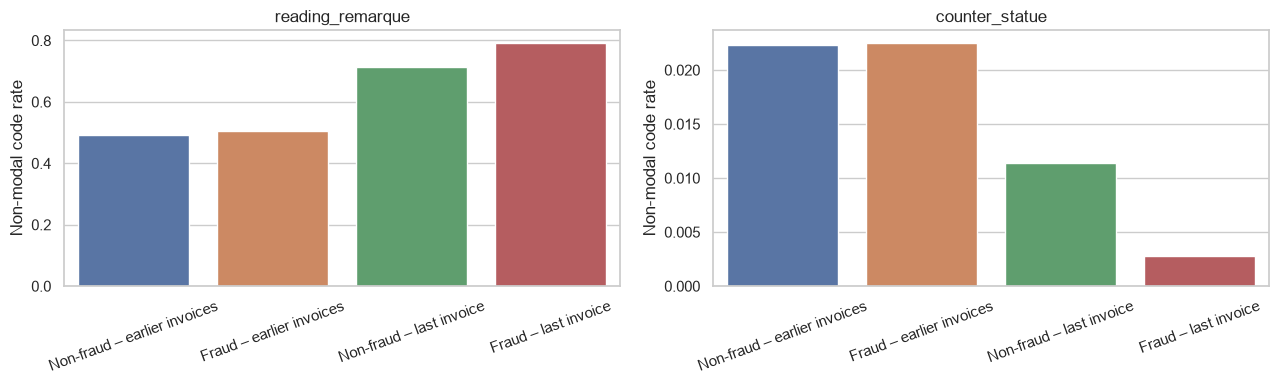

In [16]:
last_invoice_lookup = eda_analysis.set_index("client_id")["last_invoice"]
target_lookup = eda_analysis.set_index("client_id")["target"]

leakage_counts = audit_last_invoice_leakage(
    PARQUET_DIR / "invoice_train.parquet", last_invoice_lookup, target_lookup, chunk_size=CHUNK_SIZE
)

leakage_rows = []
for column in ["reading_remarque", "counter_statue"]:
    sub = leakage_counts.query("column == @column")
    modal_code = sub.groupby("code")["rows"].sum().idxmax()
    flagged = sub.assign(is_flagged=sub["code"].ne(modal_code))
    flagged_sum = flagged[flagged["is_flagged"]].groupby(["is_last_invoice", "target"])["rows"].sum()
    total_sum = flagged.groupby(["is_last_invoice", "target"])["rows"].sum()
    rate = (flagged_sum / total_sum).rename("non_modal_code_rate").reset_index()
    rate["column"] = column
    rate["modal_code"] = modal_code
    leakage_rows.append(rate)

leakage_summary = pd.concat(leakage_rows, ignore_index=True)
leakage_pivot = leakage_summary.pivot_table(
    index=["column", "modal_code"], columns=["target", "is_last_invoice"], values="non_modal_code_rate"
)
display(leakage_pivot)

for column in ["reading_remarque", "counter_statue"]:
    rates = leakage_summary.query("column == @column").set_index(["target", "is_last_invoice"])["non_modal_code_rate"]
    fraud_last = rates.get((1, True), float("nan"))
    fraud_earlier = rates.get((1, False), float("nan"))
    honest_last = rates.get((0, True), float("nan"))
    honest_earlier = rates.get((0, False), float("nan"))
    print(
        f"{column}: fraud clients' LAST invoice non-modal-code rate = {fraud_last:.1%} "
        f"(their earlier invoices: {fraud_earlier:.1%}; non-fraud clients' last invoice: {honest_last:.1%}, "
        f"earlier: {honest_earlier:.1%})"
    )

plot_df = leakage_summary.copy()
plot_df["group"] = (
    plot_df["target"].map({0: "Non-fraud", 1: "Fraud"}) + " – "
    + plot_df["is_last_invoice"].map({True: "last invoice", False: "earlier invoices"})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, column in zip(axes, ["reading_remarque", "counter_statue"]):
    data = plot_df.query("column == @column")
    sns.barplot(data=data, x="group", y="non_modal_code_rate", hue="group", legend=False, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    ax.set_ylabel("Non-modal code rate")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 6. A few more diagnostic views

A visual check on the index-reconciliation question above (does a client's index movement track
its billed consumption, and does that differ by `counter_statue` or `target`?), and a calendar-year
view of invoice volume and average consumption to catch any cohort or recording-practice shift
across the 1977–2019 span, before treating "recent vs. historical" features as straightforwardly
comparable across a client's whole history.

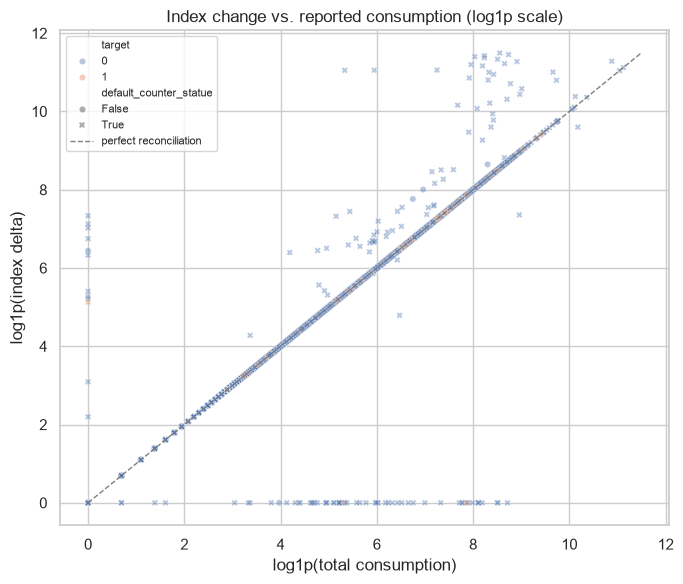

In this sample, 0.6% of invoices have an index/consumption gap larger than 10 units.


In [17]:
row_group_indices = sorted(set([0, max(invoice_parquet.num_row_groups // 2, 0), invoice_parquet.num_row_groups - 1]))
scatter_columns = ["client_id", "old_index", "new_index", *CONSUMPTION_COLUMNS, "counter_statue"]
scatter_frames = []
for row_group in row_group_indices:
    row_group_df = invoice_parquet.read_row_group(row_group, columns=scatter_columns).to_pandas()
    scatter_frames.append(row_group_df.sample(n=min(15_000, len(row_group_df)), random_state=RANDOM_STATE))

scatter_sample = pd.concat(scatter_frames, ignore_index=True)
scatter_sample["client_id"] = scatter_sample["client_id"].astype("string")
scatter_sample["counter_statue"] = scatter_sample["counter_statue"].astype("string")
scatter_sample["total_consumption"] = scatter_sample[CONSUMPTION_COLUMNS].sum(axis=1)
scatter_sample["index_delta"] = scatter_sample["new_index"] - scatter_sample["old_index"]
scatter_sample = scatter_sample.merge(eda_analysis[["client_id", "target"]], on="client_id", how="inner")
scatter_sample["log1p_index_delta"] = np.log1p(scatter_sample["index_delta"].clip(lower=0))
scatter_sample["log1p_total_consumption"] = np.log1p(scatter_sample["total_consumption"].clip(lower=0))
scatter_sample["default_counter_statue"] = scatter_sample["counter_statue"].eq("0")

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=scatter_sample, x="log1p_total_consumption", y="log1p_index_delta",
    hue="target", style="default_counter_statue", alpha=0.4, s=20, ax=ax,
)
axis_max = scatter_sample[["log1p_total_consumption", "log1p_index_delta"]].to_numpy().max()
ax.plot([0, axis_max], [0, axis_max], color="grey", linestyle="--", linewidth=1, label="perfect reconciliation")
ax.set(title="Index change vs. reported consumption (log1p scale)",
       xlabel="log1p(total consumption)", ylabel="log1p(index delta)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

mismatch_share = ((scatter_sample["index_delta"] - scatter_sample["total_consumption"]).abs() > 10).mean()
print(f"In this sample, {mismatch_share:.1%} of invoices have an index/consumption gap larger than 10 units.")

**Two real results out of this matrix, worth carrying into §7:**

- `active_days`, `invoice_count`, and `customer_tenure_days_at_last_invoice` are the three
  **strongest** linear correlates with `target` (~0.10–0.13) — modest in absolute terms, but this
  is the observation-window bias from §7 showing up quantitatively, from a completely different
  angle (linear correlation vs. quintile fraud rates) and agreeing with it.
- `reconciliation_gap_abs_mean` correlates with `target` at essentially **zero** (0.004) here,
  which looks like it contradicts the §4 finding that fraud clients have a 65% higher mean
  mismatch (126.2 vs. 76.5). It doesn't — Pearson correlation is sensitive to linear structure and
  gets washed out by a heavy-tailed variable with a handful of extreme values, while the group-mean
  comparison in §4 captures the same raw difference more directly. Lesson: for skewed variables,
  don't rely on a correlation coefficient alone to judge whether a difference is real. The same
  variable's strong correlation with `mean_months` (0.82) likely reflects a handful of clients
  whose corrupted rows (see the `months_number` fix in §4) drive up both aggregates together,
  rather than a genuine relationship between billing period and reconciliation error.

**Correlation heatmap.** Pearson correlation across the client-level features (plus the
index-reconciliation features from §4) and the binary `target`. Two things to read from it:

- **Target correlations are expected to be weak.** A single linear correlation with a rare binary
  outcome (5.58% base rate) rarely looks strong even when a feature is genuinely useful in a
  model — this is a sanity check, not a feature-selection step on its own.
- **Feature-feature correlations flag redundancy**, e.g. `invoice_count` vs. `active_days`, or the
  reconciliation-count features vs. `invoice_count` (expected — clients with more invoices simply
  get more chances to show *any* rare event, the same observation-window confound flagged in §7).
  The most-correlated pairs printed below are candidates for the correlation-threshold pruning
  described in `00_project_plan.md` §3.1.

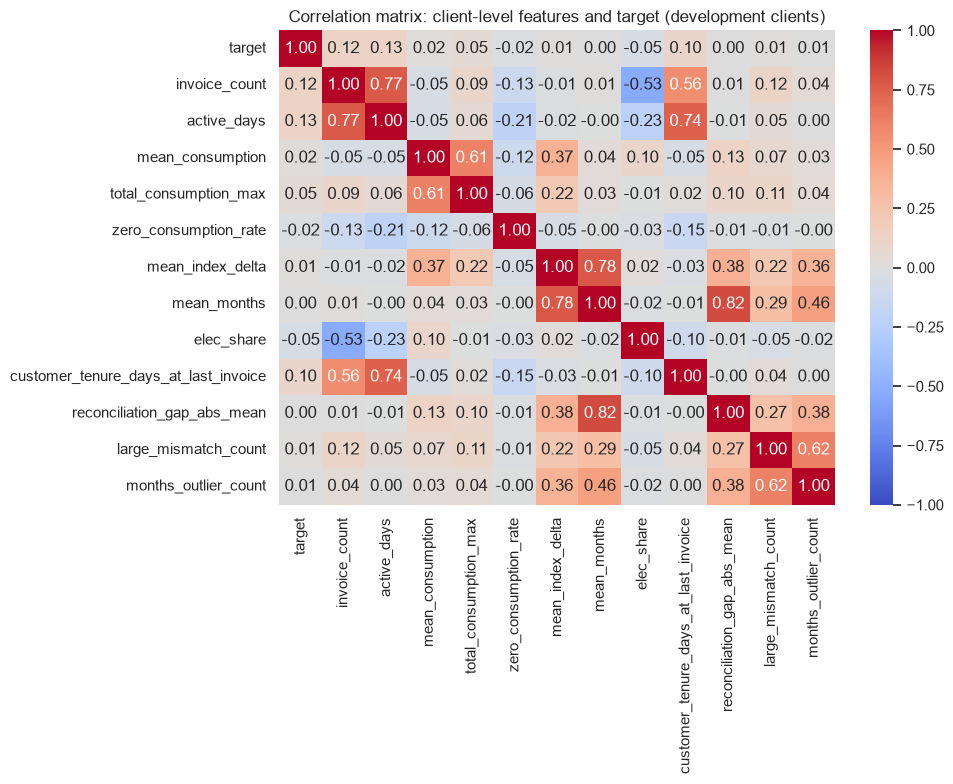

,correlation_with_target
active_days,0.127225
invoice_count,0.124565
customer_tenure_days_at_last_invoice,0.097218
elec_share,-0.051292
total_consumption_max,0.048447
zero_consumption_rate,-0.021784
mean_consumption,0.020101
large_mismatch_count,0.009396
mean_index_delta,0.008368
months_outlier_count,0.006146


Most correlated feature pairs (candidates to prune per 00_project_plan.md §3.1):


,,abs_correlation
reconciliation_gap_abs_mean,mean_months,0.820342
mean_months,mean_index_delta,0.777893
active_days,invoice_count,0.769789
customer_tenure_days_at_last_invoice,active_days,0.742884
months_outlier_count,large_mismatch_count,0.615984


In [18]:
corr_features = eda_analysis[["client_id", "target"] + eda_features].merge(
    meter_recon[["client_id", "reconciliation_gap_abs_mean", "large_mismatch_count", "months_outlier_count"]],
    on="client_id", how="left",
)
corr_matrix = corr_features.drop(columns="client_id").corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix: client-level features and target (development clients)")
plt.tight_layout()
plt.show()

target_corr = corr_matrix["target"].drop("target")
ranked_target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(ranked_target_corr.rename("correlation_with_target").to_frame())

feature_corr = corr_matrix.drop(index="target", columns="target")
upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape, dtype=bool), k=1))
top_pairs = upper_triangle.unstack().dropna().abs().sort_values(ascending=False).head(5)
print("Most correlated feature pairs (candidates to prune per 00_project_plan.md §3.1):")
display(top_pairs.rename("abs_correlation").to_frame())

## 7. Record findings before modeling

First pass filled in from the numbers computed above — discuss and revise together before
freezing the baseline feature set. This is the evidence base for the baseline-model and slide
decisions.

- **Class imbalance.** 5.58% fraud rate, confirmed exactly on the development split. Use PR-AUC,
  not accuracy, as the headline metric (per `README.md`).

- **Real, trustworthy segment signal.** `client_catg == 51` has a **16.9% fraud rate** on 1,299
  development clients — about 3× the base rate, and a large enough sample to trust, not noise.
  `disrict`/`region` fraud rates vary roughly 2–3× across categories (`disrict` 3.6%–7.1%; `region`
  up to ~10.3% for region 103). Worth encoding as categorical features and worth checking model
  performance per-segment later, not just a single global score.

- **Observation-window bias is the single biggest risk in this dataset.** Fraud rate is **9.6×
  higher** in the longest-history invoice-count quintile (9.0%) than the shortest (0.9%), and it
  rises close to monotonically across the five bins. A model trained naively on this will partly
  learn "has been a customer a long time" rather than "is committing fraud" — which will not
  generalize to newer clients. This needs an explicit answer before modeling: compare performance
  within tenure/history-length bands, and treat history length as a feature whose effect we
  understand rather than an accidental proxy.

- **A major, previously-unknown cohort effect: real invoice record-keeping only starts at scale in
  2005.** Invoice volume jumps from ~2,159/year in 2004 to 64,663 in 2005, then 200k–410k/year from
  2006–2019. `creation_date` spans back to 1977, but invoices before 2005 are a thin trickle by
  comparison. This means customer tenure (from `creation_date`) and invoice-history span (first to
  last invoice) can diverge a lot for older clients — treat "recent vs. historical" comparisons
  with caution for any client whose earliest invoice falls before 2005, since that early history is
  sparse rather than a clean, continuous record.

- **The index-reconciliation check is a real, promising signal.** Mean absolute mismatch between
  `new_index − old_index` and reported consumption is **76.5 for non-fraud clients vs. 126.2 for
  fraud clients** (about 65% higher). The *median* mismatch is 0 for both groups, though — this is
  driven by a subset of invoices with large mismatches, not a uniform shift, so a count/max-based
  feature (e.g. `large_mismatch_count`) is likely more useful than a plain mean. Fraud clients are
  also somewhat more likely to have at least one such mismatch (8.7% vs. 5.6% of clients) — though
  this "at least one" framing is itself partly confounded by the observation-window bias above,
  since clients with more invoices simply get more chances to show a mismatch.

- **`months_number` — corrected finding.** An initial check using a fixed "valid" set of
  `{1,2,3,4,6,12}` flagged 7% of rows as outliers, which overstated the problem: the real full-file
  distribution shows `8, 16, 10, 20, 14, 24, 18` are also common, legitimate multi-period bills.
  Switching to a physically-implausible threshold (>36 months) shows the real problem is much
  smaller — about 0.04% of rows — but it does include genuinely corrupted values (max seen:
  636,624 "months"). Those extreme rows must still be capped/removed before any `mean`/`sum`
  aggregation (including the existing `mean_months` feature above), since a single such row would
  badly distort a per-client average.

- **`counter_statue` is dirtier than a first sample suggested, but only barely, in volume.** The
  full file contains genuinely invalid codes (`269375`, `618`, `420`, `46`, `769`, `'A'`) matching
  what the 4th-place Zindi solution had to clean (`00_project_plan.md` §4.4) — but only **47 rows
  out of 4.47M** (0.001%). A tiny, easy cleaning step (map to the nearest valid 0–5 code or drop),
  not a major data-quality blocker.

- **Leakage audit: real, but more nuanced than a single "smoking gun."** `reading_remarque` shows
  a broad shift toward non-modal codes at a client's *last* invoice for **everyone** — non-fraud
  clients go from 49.1% (earlier) to 71.4% (last); fraud clients go from 50.5% to **79.3%**. The
  shift is somewhat larger for fraud clients, but it's not unique to them, which suggests a general
  end-of-relationship recording pattern (e.g. a different kind of visit/reading right before an
  account closes) rather than fraud-specific leakage alone. `counter_statue` moves in the *opposite*
  direction — the non-default-status rate *drops* at the last invoice for both groups, and drops
  further for fraud clients specifically (2.3%→0.3%, vs. 2.2%→1.1% for non-fraud). Whatever the
  mechanism (meter replacement/reset as part of closing out an account?), **something changes for
  everyone right before a client's relationship ends, in both fields, in different directions** —
  which is exactly the kind of feature that should not be trusted as an available-in-advance
  predictor. Recommendation: don't use last-invoice-specific values of `reading_remarque`/
  `counter_statue` as features; if used at all, use only values from invoices before some
  meaningful cutoff, and say so explicitly in the slides.

- **Other data-quality counts** (all real, all small relative to 135k clients): 11 duplicate
  invoice-row hash matches, 1,816 clients with a backwards index at some point, 397 with negative
  computed tenure, and 8,748 where `creation_date` falls after the first recorded invoice — worth a
  closer look at whether that last one is a data-entry artifact or a legitimate backfill pattern,
  but not large enough to block modeling.

- **Stakeholder decision, still open:** what is the weekly/monthly inspection capacity `k`, and
  what hit rate makes deployment valuable? Needed to turn PR-AUC into a concrete precision@k/
  recall@k operating point (`README.md`).

### Recommended next feature iteration

1. Add standard deviation and robust quantiles of consumption/index deltas.
2. Compare recent (e.g. last 6–12 months) behavior with each client's earlier history — being
   mindful of the 2005 cohort effect above when defining "historical."
3. Count meters, tariffs, statuses, and status changes per client; clean the 47 genuinely-invalid
   `counter_statue` rows and cap/flag `months_number` values above 36.
4. Add the index-reconciliation features (`reconciliation_gap_abs_mean`, `large_mismatch_count`)
   from §4 above — real signal, worth carrying into the baseline model.
5. Add time gaps, invoice regularity, trend, sudden-drop, and sudden-spike features.
6. Treat client/region/category codes as categorical; never use `client_id` as a predictor.
7. Exclude or lag last-invoice-specific `reading_remarque`/`counter_statue` values per the leakage
   audit above.
8. Build the Day 2 baseline before expanding further, then let error analysis determine the next
   features — and check performance within history-length bands given the observation-window bias.

In [19]:
if SAVE_FEATURES:
    output_dir = DATA_DIR / "processed"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "train_client_features.csv"
    analysis.to_csv(output_path, index=False)
    print(f"Saved {len(analysis):,} client rows to {output_path}")
else:
    print("Feature saving is disabled. Set SAVE_FEATURES = True when the table is ready to share locally.")

Feature saving is disabled. Set SAVE_FEATURES = True when the table is ready to share locally.
